## 선형모델(L1, L2 규제)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler # 전처리기
from sklearn.model_selection import train_test_split # 나누는 거
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression # 학습 모델
from sklearn.metrics import roc_auc_score # 학습 모델 결과 보는 용

## 분류

In [118]:
cancer = load_breast_cancer()
X, y = cancer["data"], cancer["target"]
print(X.shape, y.shape)
# (569,) 관측한 환자가 569명이라는 뜻
# (569, 30) 층정 개수가 30개 하지만, 항목이 30개는 아닐 수 있다
# 카테고리 너무 많으면 학습이 안 됨 그래서 필요없는 것은 drop해야 함

(569, 30) (569,)


In [119]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # 평균으로 부터 분산 내에 있는 것을 모아서???

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # 전처리 --------

(455, 30) (114, 30) (455,) (114,)


In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # 전처리 --------

(455, 30) (114, 30) (455,) (114,)


In [ ]:
# LogisticRegression -> C를 이용해서 규제 강도를 결정
# 작은 거 < 0.1 < 큰 거 (1.0이 중앙)
# 강한 규제 < 일반 규제 < 규제를 해제 (C가 커질 수록 과적합에 가까워짐)
lr = LogisticRegression(max_iter=5000) # LogisticRegression는 C를 결정하세요?
lr.fit(X_train, y_train)
# 데이터가 작을 수록 없는 특성도 발현시켜서 해야 함 C값 올림

In [122]:
# L2는 일반화 성능에 관심이 있으면 L2를 선택하는 경향이 있음
# L1은 주요한 특성을 스스로 고려하는 모델의 경우 선택하는 경향이 있음 => 모델을 해석하는 데 용이 (반대로 0이 아닌 것은 알고리즘에 중요한 것임을 알 수 있음)
models = {
    "OLS": LogisticRegression(penalty=None, max_iter=5000), # y = a*w + b 5000번 선 긋는 거 최적화될 때까지
    "Ridge(L2)": LogisticRegression(penalty="l2", solver='lbfgs', max_iter=5000), # 기울기를 0으로 수렴하도록 선을 긋는 것, w의 특징이 작지만 그대로 발현, 학습 효율 좋지 않지만 일반화에 도움 됨 (양이 많을 때 좋음)
    "Lasso(L1)": LogisticRegression(penalty="l1", solver='liblinear', max_iter=5000) # 얘는 정말로 특정 개수는 0으로 만들어버림
    # 'lbfgs' 수학 알고리즘임
}

In [123]:
result = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    result[name] = auc

C:\Users\user\AppData\Local\Programs\Python\Python39\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [124]:
result

{'OLS': np.float64(0.9963969865705863),
 'Ridge(L2)': np.float64(0.9977071732721913),
 'Lasso(L1)': np.float64(0.9977071732721914)}

In [125]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5) # default가 n_neighbors=5
knn.fit(X_train, y_train)

KNeighborsClassifier()

- KNeighborsClassifier 매개변수

algorithm : {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'
        Algorithm used to compute the nearest neighbors:

        - 'ball_tree' will use :class:`BallTree` => 30차원 이상 시 사용
        - 'kd_tree' will use :class:`KDTree` => 15차원 정도일 때 사용
        - 'brute' will use a brute-force search.
        - 'auto' will attempt to decide the most appropriate algorithm
          based on the values passed to :meth:`fit` method.

n_jobs : int, default=None
        The number of parallel jobs to run for neighbors search.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.
        Doesn't affect :meth:`fit` method.

=> cpu 전부 써서 돌려줌
=> 테스트 끝나고 빨리 돌려야 할 때 사용

In [126]:
y_pred = knn.predict(X_test)
print(knn.score(X_test, y_test)) # 학습데이터
print(np.mean(y_pred == y_test)) # 예측데이터
# 0.956140350877193
# 0.956140350877193 --> 과적합이네

0.956140350877193
0.956140350877193


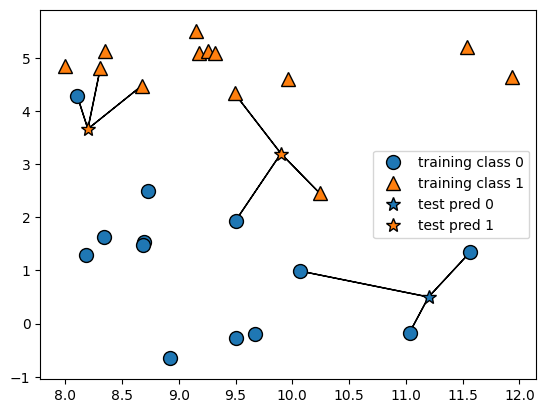

In [127]:
import mglearn
mglearn.plots.plot_knn_classification(n_neighbors=3) # 일반적으로 3, 5를 많이 씀 & 짝수는 절대 안 씀

## 회귀

In [128]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X, y = housing["data"], housing["target"]
print(X.shape, y.shape) # 집에 가기전에 재시작 누르고 모두 실행해서 에러 안 나는지 확인해야 함 ipynb에서는 변수가 남아있을 수 있으니까 .py에서는 오류 날 수 있음

(20640, 8) (20640,)


In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # 전처리 --------

(16512, 8) (4128, 8) (16512,) (4128,)


In [131]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5) # default가 n_neighbors=5
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [135]:
from sklearn.metrics import mean_squared_error
y_pred = knn.predict(X_test)
# print(knn.score(X_test, y_test)) # 학습데이터
print(mean_squared_error(y_pred, y_test))

1.1186823858768293


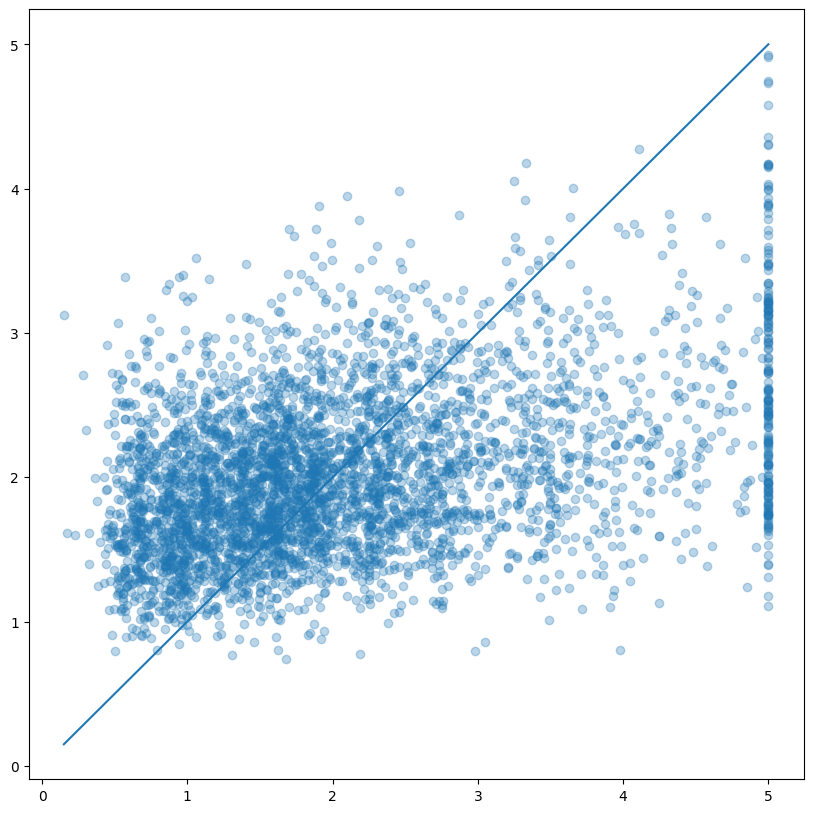

In [136]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.gray()
plt.show()

naive bayes
- 예측이 굉장히 빠름 (학습이 빠르다고 하지 않았음) => 사전 확률을 구해놨기 때문 (이건 컴퓨터가 빠르게 계산함)
- 파라미터에 비교적 둔감
- "*고차원 희소 데이터에 잘 작동" (*고차원 희소 데이터 ex. 지도에 사람 하나, 아마존에서 내가 뭘 살까)
- 단점 : 선형 모델보다 "항상" 낮은 성능

knn
- 비지도학습에 효율적
- 직관적

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split # 나누는 거
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [149]:
cancer = load_breast_cancer()
X, y = cancer["data"], cancer["target"]
print(X.shape, y.shape)

(569, 30) (569,)


In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # 전처리 --------

(455, 30) (114, 30) (455,) (114,)


In [151]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [152]:
y_pred = gnb.predict(X_test)
print(accuracy_score(y_pred, y_test))

0.9736842105263158
